# Deep Learning Fundamentals - Mini-Project

## MNIST Digits - CNN Hyperparameters and Model Evaluation

### Imports and global state initialization

In [1]:
import torch
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

from mnist_datamodule import MNISTDataModule
from mnist_cnn_classifier import MNISTCNN
from batch_size_evaluator import BatchSizeEvaluator
from hyperparameter_evaluator import HyperParameterEvaluator

In [2]:
if torch.cuda.is_available():
    torch.set_float32_matmul_precision("high")

/home/logus/env/iscte/mnist_digits/lib/python3.10/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [3]:
EPOCHS_SWEEP = 10
SEED = 42

### Initial baseline settings

In [4]:
baseline = dict(
    batch_size=256,
    lr=5e-4,
    optimizer="adam",
    weight_decay=1e-4,
    activation="gelu",
    width=128,
    depth=3,
    dropout_p=0.0,
    use_bn=False,
    weight_init="xavier",
)

In [5]:
# Helper function to cast a selected value to the same type as the baseline entry
def cast_like(v, like):
    v_py = v.item() if hasattr(v, "item") else v
    return type(like)(v_py)

### Define experimentation sweeps

In [6]:
# Sweep name, friendly title, candidate values
sweeps = [
    ("batch_size",   "Batch Size",               [64, 128, 256, 512]),
    ("width",        "Neurons per Hidden Layer", [64, 128, 256, 512]),
    ("depth",        "Hidden Layers (Depth)",    [1, 2, 3]),
    ("dropout_p",    "Dropout Probability",      [0.0, 0.1, 0.2, 0.5]),
    ("use_bn",       "BatchNorm",                [False, True]),
    ("lr",           "Learning Rate",            [5e-4, 8e-4, 1e-3, 2e-3]),
    ("weight_decay", "L2 Weight Decay",          [1e-4, 5e-4, 1e-3]),
    ("activation",   "Activation",               ["relu", "leakyrelu", "gelu", "elu", "tanh", "sigmoid"]),
    ("weight_init",  "Weight Initialization",    ["he", "xavier"]),
    ("optimizer",    "Optimizer",                ["adam", "adamw", "sgd", "rmsprop"]),
]

### Run experiment with batch size and all sweeps sequentially

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/logus/env/iscte/mnist_digits/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default



*** SWEEP: batch_size


***[RUN] batch_size=64 | seed=42
       hparams: width=128, depth=3, lr=0.0005, dropout_p=0.0, use_bn=False, act=gelu
       dataloader: batch_size=64, augment=True


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 133 K  | train
1 | head      | Linear             | 1.3 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
134 K     Trainable params
0         Non-trainable params
134 K     Total params
0.539     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode


Epoch 9: 100%|██████████| 860/860 [00:04<00:00, 196.14it/s, v_num=16, train_loss_step=0.0215, val_loss=0.0649, val_acc=0.980, lr=0.0005, train_loss_epoch=0.114, train_acc=0.960] 

`Trainer.fit` stopped: `max_epochs=10` reached.


...


***[RESULT] batch_size=256 → best_val_acc=0.9749 (epoch 9), final_val_acc=0.9749 | best_val_loss=0.0760 (epoch 9), final_val_loss=0.0792


***[RUN] batch_size=512 | seed=42
       hparams: width=128, depth=3, lr=0.0005, dropout_p=0.0, use_bn=False, act=gelu
       dataloader: batch_size=512, augment=True


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 133 K  | train
1 | head      | Linear             | 1.3 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
134 K     Trainable params
0         Non-trainable params
134 K     Total params
0.539     Total estimated model params size (MB)
12        Modules in train

Epoch 9: 100%|██████████| 108/108 [00:01<00:00, 67.10it/s, v_num=19, train_loss_step=0.177, val_loss=0.0893, val_acc=0.972, lr=0.0005, train_loss_epoch=0.148, train_acc=0.953]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 108/108 [00:01<00:00, 66.67it/s, v_num=19, train_loss_step=0.177, val_loss=0.0893, val_acc=0.972, lr=0.0005, train_loss_epoch=0.148, train_acc=0.953]

***[RESULT] batch_size=512 → best_val_acc=0.9721 (epoch 9), final_val_acc=0.9721 | best_val_loss=0.0893 (epoch 10), final_val_loss=0.0893
     param  value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
batch_size     64      0.976833           9       0.976833       0.064912               10        0.064912
batch_size    128      0.975475           9       0.975475       0.071852               10        0.071852
batch_size    256      0.974928           9       0.974928       0.075978                9        0.079160
batch_size    512      0.972082           9       0.972082       0.089314               10        0.089314


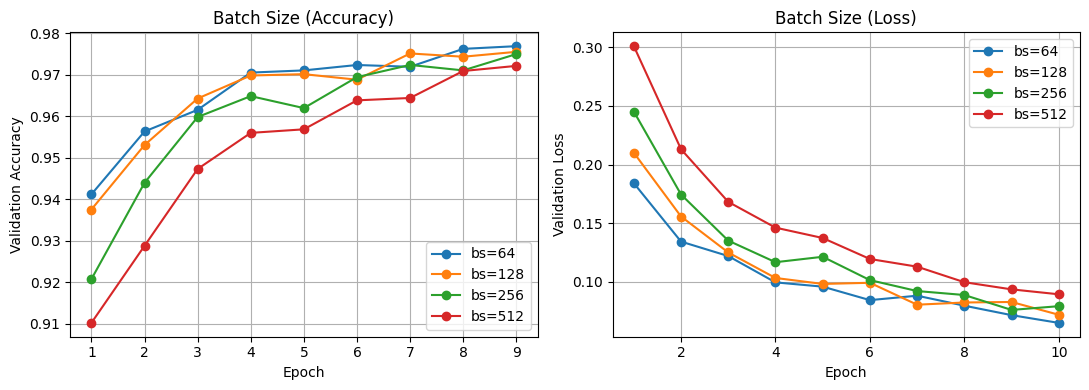

Seed set to 42


[selected] batch_size = 64

*** SWEEP: width

***[RUN] width=64 | seed=42
    hparams: activation=gelu, depth=3, dropout_p=0.0, lr=0.0005, optimizer=adam, use_bn=False, weight_decay=0.0001, weight_init=xavier, width=64


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | GELU               | 0      | train
1 | encoder   | Sequential         | 222 K  | train
2 | head      | Sequential         | 74.4 K | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.186     Total estimat

Epoch 9: 100%|██████████| 860/860 [00:07<00:00, 116.42it/s, v_num=4, train_loss_step=0.00553, val_loss=0.0176, val_acc=0.994, lr=0.0005, train_loss_epoch=0.0274, train_acc=0.990] 

`Trainer.fit` stopped: `max_epochs=10` reached.


...

***[RESULT] width=256 → best_val_acc=0.9924 (epoch 9), final_val_acc=0.9924 | best_val_loss=0.0234 (epoch 2), final_val_loss=0.0244


***[RUN] width=512 | seed=42
    hparams: activation=gelu, depth=3, dropout_p=0.0, lr=0.0005, optimizer=adam, use_bn=False, weight_decay=0.0001, weight_init=xavier, width=512


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | GELU               | 0      | train
1 | encoder   | Sequential         | 14.2 M | train
2 | head      | Sequential         | 4.7 M  | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
18.9 M    Trainable params
0         Non-trainable params
18.9 M    Total params
75.549    Total estimat

Epoch 9: 100%|██████████| 860/860 [00:13<00:00, 64.10it/s, v_num=7, train_loss_step=0.0979, val_loss=0.0263, val_acc=0.992, lr=0.0005, train_loss_epoch=0.0326, train_acc=0.989]  

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 860/860 [00:13<00:00, 62.66it/s, v_num=7, train_loss_step=0.0979, val_loss=0.0263, val_acc=0.992, lr=0.0005, train_loss_epoch=0.0326, train_acc=0.989]
***[RESULT] width=512 → best_val_acc=0.9925 (epoch 8), final_val_acc=0.9923 | best_val_loss=0.0249 (epoch 4), final_val_loss=0.0263

param  value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
width    128      0.994072           9       0.994072       0.017622                9        0.019653
width    512      0.992494           8       0.992275       0.024904                4        0.026284
width    256      0.992416           9       0.992416       0.023389                2        0.024360
width     64      0.992079           6       0.991263       0.017561               10        0.017561


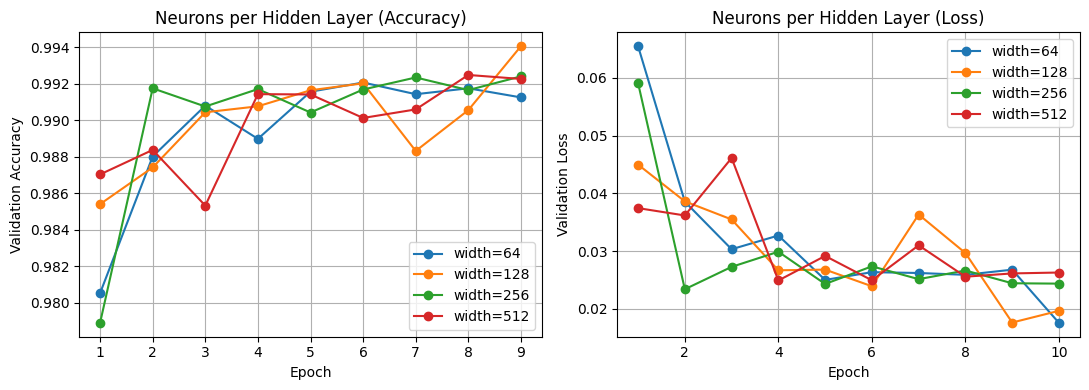

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[selected] width = 128

*** SWEEP: depth

***[RUN] depth=1 | seed=42
    hparams: activation=gelu, depth=1, dropout_p=0.0, lr=0.0005, optimizer=adam, use_bn=False, weight_decay=0.0001, weight_init=xavier, width=128


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | GELU               | 0      | train
1 | encoder   | Sequential         | 1.3 K  | train
2 | head      | Sequential         | 3.2 M  | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
3.2 M     Trainable params
0         Non-trainable params
3.2 M     Total params
12.856    Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode


Epoch 9: 100%|██████████| 860/860 [00:04<00:00, 178.95it/s, v_num=3, train_loss_step=0.164, val_loss=0.0401, val_acc=0.986, lr=0.0005, train_loss_epoch=0.0653, train_acc=0.978]  

`Trainer.fit` stopped: `max_epochs=10` reached.


...

***[RESULT] depth=2 → best_val_acc=0.9922 (epoch 6), final_val_acc=0.9909 | best_val_loss=0.0233 (epoch 10), final_val_loss=0.0233


***[RUN] depth=3 | seed=42
    hparams: activation=gelu, depth=3, dropout_p=0.0, lr=0.0005, optimizer=adam, use_bn=False, weight_decay=0.0001, weight_init=xavier, width=128


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | GELU               | 0      | train
1 | encoder   | Sequential         | 886 K  | train
2 | head      | Sequential         | 296 K  | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.731     Total estimat

Epoch 9: 100%|██████████| 860/860 [00:05<00:00, 168.49it/s, v_num=5, train_loss_step=0.150, val_loss=0.0197, val_acc=0.993, lr=0.0005, train_loss_epoch=0.0282, train_acc=0.991]   

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 860/860 [00:05<00:00, 167.84it/s, v_num=5, train_loss_step=0.150, val_loss=0.0197, val_acc=0.993, lr=0.0005, train_loss_epoch=0.0282, train_acc=0.991]
***[RESULT] depth=3 → best_val_acc=0.9941 (epoch 9), final_val_acc=0.9941 | best_val_loss=0.0176 (epoch 9), final_val_loss=0.0197

param  value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
depth      3      0.994072           9       0.994072       0.017622                9        0.019653
depth      2      0.992194           6       0.990900       0.023268               10        0.023268
depth      1      0.989152           9       0.989152       0.039837                9        0.040084


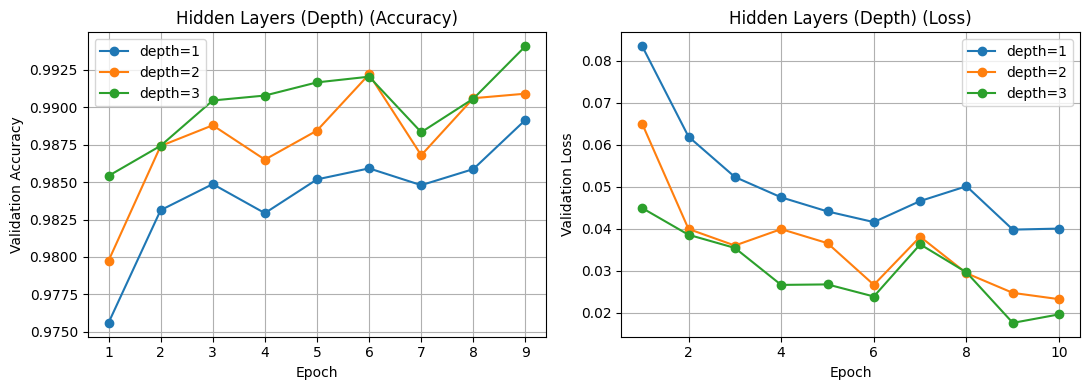

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[selected] depth = 3

*** SWEEP: dropout_p

***[RUN] dropout_p=0.0 | seed=42
    hparams: activation=gelu, depth=3, dropout_p=0.0, lr=0.0005, optimizer=adam, use_bn=False, weight_decay=0.0001, weight_init=xavier, width=128


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | GELU               | 0      | train
1 | encoder   | Sequential         | 886 K  | train
2 | head      | Sequential         | 296 K  | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.731     Total estimated model params size (MB)
20        Modules in train mode
0         Modules in eval mode


Epoch 9: 100%|██████████| 860/860 [00:04<00:00, 180.43it/s, v_num=4, train_loss_step=0.00227, val_loss=0.0235, val_acc=0.993, lr=0.0005, train_loss_epoch=0.0262, train_acc=0.992] 

`Trainer.fit` stopped: `max_epochs=10` reached.


...

***[RESULT] dropout_p=0.2 → best_val_acc=0.9937 (epoch 9), final_val_acc=0.9937 | best_val_loss=0.0194 (epoch 10), final_val_loss=0.0194


***[RUN] dropout_p=0.5 | seed=42
    hparams: activation=gelu, depth=3, dropout_p=0.5, lr=0.0005, optimizer=adam, use_bn=False, weight_decay=0.0001, weight_init=xavier, width=128


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | GELU               | 0      | train
1 | encoder   | Sequential         | 886 K  | train
2 | head      | Sequential         | 296 K  | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.731     Total estimat

Epoch 9: 100%|██████████| 860/860 [00:05<00:00, 171.88it/s, v_num=7, train_loss_step=0.0921, val_loss=0.0206, val_acc=0.993, lr=0.0005, train_loss_epoch=0.038, train_acc=0.988]   

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 860/860 [00:05<00:00, 171.21it/s, v_num=7, train_loss_step=0.0921, val_loss=0.0206, val_acc=0.993, lr=0.0005, train_loss_epoch=0.038, train_acc=0.988]
***[RESULT] dropout_p=0.5 → best_val_acc=0.9935 (epoch 9), final_val_acc=0.9935 | best_val_loss=0.0177 (epoch 9), final_val_loss=0.0206

    param  value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
dropout_p    0.0      0.994501           8       0.993092       0.018377                8        0.023491
dropout_p    0.1      0.993767           5       0.991572       0.019079               10        0.019079
dropout_p    0.2      0.993667           9       0.993667       0.019372               10        0.019372
dropout_p    0.5      0.993537           9       0.993537       0.017688                9        0.020630


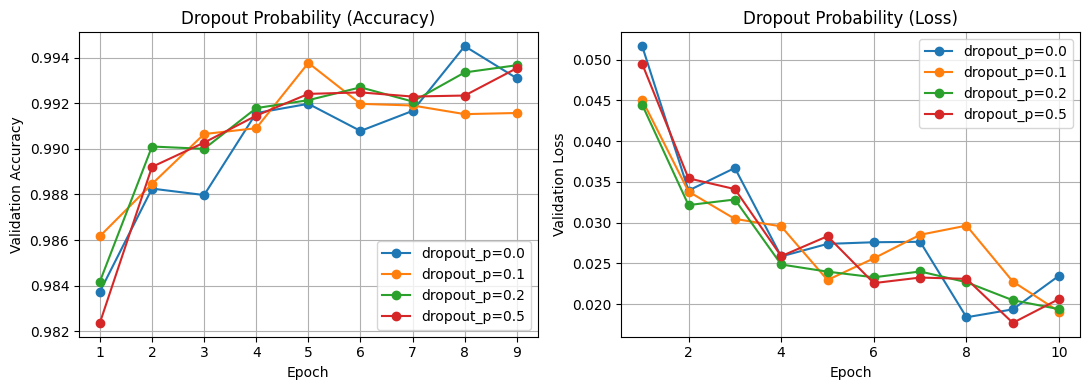

Seed set to 42


[selected] dropout_p = 0.0

*** SWEEP: use_bn

***[RUN] use_bn=False | seed=42
    hparams: activation=gelu, depth=3, dropout_p=0.0, lr=0.0005, optimizer=adam, use_bn=False, weight_decay=0.0001, weight_init=xavier, width=128


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | GELU               | 0      | train
1 | encoder   | Sequential         | 886 K  | train
2 | head      | Sequential         | 296 K  | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.731     Total estimat

Epoch 9: 100%|██████████| 860/860 [00:07<00:00, 117.86it/s, v_num=2, train_loss_step=0.00227, val_loss=0.0235, val_acc=0.993, lr=0.0005, train_loss_epoch=0.0262, train_acc=0.992] 

`Trainer.fit` stopped: `max_epochs=10` reached.


...

***[RESULT] use_bn=False → best_val_acc=0.9945 (epoch 8), final_val_acc=0.9931 | best_val_loss=0.0184 (epoch 8), final_val_loss=0.0235


***[RUN] use_bn=True | seed=42
    hparams: activation=gelu, depth=3, dropout_p=0.0, lr=0.0005, optimizer=adam, use_bn=True, weight_decay=0.0001, weight_init=xavier, width=128


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | GELU               | 0      | train
1 | encoder   | Sequential         | 887 K  | train
2 | head      | Sequential         | 296 K  | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.734     Total estimat

Epoch 9: 100%|██████████| 860/860 [00:05<00:00, 166.36it/s, v_num=3, train_loss_step=0.00202, val_loss=0.033, val_acc=0.989, lr=0.0005, train_loss_epoch=0.0338, train_acc=0.989]  

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 860/860 [00:05<00:00, 165.78it/s, v_num=3, train_loss_step=0.00202, val_loss=0.033, val_acc=0.989, lr=0.0005, train_loss_epoch=0.0338, train_acc=0.989]
***[RESULT] use_bn=True → best_val_acc=0.9936 (epoch 9), final_val_acc=0.9936 | best_val_loss=0.0238 (epoch 9), final_val_loss=0.0330

 param  value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
use_bn  False      0.994501           8       0.993092       0.018377                8        0.023491
use_bn   True      0.993579           9       0.993579       0.023822                9        0.033033


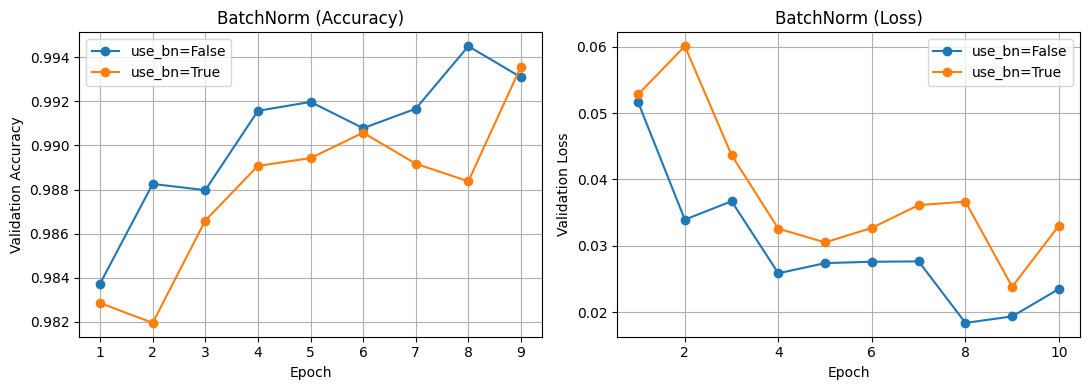

Seed set to 42


[selected] use_bn = False

*** SWEEP: lr

***[RUN] lr=0.0005 | seed=42
    hparams: activation=gelu, depth=3, dropout_p=0.0, lr=0.0005, optimizer=adam, use_bn=False, weight_decay=0.0001, weight_init=xavier, width=128


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | GELU               | 0      | train
1 | encoder   | Sequential         | 886 K  | train
2 | head      | Sequential         | 296 K  | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.731     Total estimat

Epoch 9: 100%|██████████| 860/860 [00:04<00:00, 176.04it/s, v_num=4, train_loss_step=0.00227, val_loss=0.0235, val_acc=0.993, lr=0.0005, train_loss_epoch=0.0262, train_acc=0.992] 

`Trainer.fit` stopped: `max_epochs=10` reached.


...

***[RESULT] lr=0.001 → best_val_acc=0.9933 (epoch 6), final_val_acc=0.9921 | best_val_loss=0.0212 (epoch 6), final_val_loss=0.0225


***[RUN] lr=0.002 | seed=42
    hparams: activation=gelu, depth=3, dropout_p=0.0, lr=0.002, optimizer=adam, use_bn=False, weight_decay=0.0001, weight_init=xavier, width=128


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | GELU               | 0      | train
1 | encoder   | Sequential         | 886 K  | train
2 | head      | Sequential         | 296 K  | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.731     Total estimat

Epoch 9: 100%|██████████| 860/860 [00:04<00:00, 173.52it/s, v_num=7, train_loss_step=0.0738, val_loss=0.0268, val_acc=0.993, lr=0.002, train_loss_epoch=0.0438, train_acc=0.986]  

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 860/860 [00:04<00:00, 172.92it/s, v_num=7, train_loss_step=0.0738, val_loss=0.0268, val_acc=0.993, lr=0.002, train_loss_epoch=0.0438, train_acc=0.986]
***[RESULT] lr=0.002 → best_val_acc=0.9923 (epoch 9), final_val_acc=0.9923 | best_val_loss=0.0268 (epoch 10), final_val_loss=0.0268

param  value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
   lr 0.0005      0.994501           8       0.993092       0.018377                8        0.023491
   lr 0.0010      0.993267           6       0.992076       0.021200                6        0.022527
   lr 0.0008      0.992387           9       0.992387       0.021489                9        0.023690
   lr 0.0020      0.992261           9       0.992261       0.026773               10        0.026773


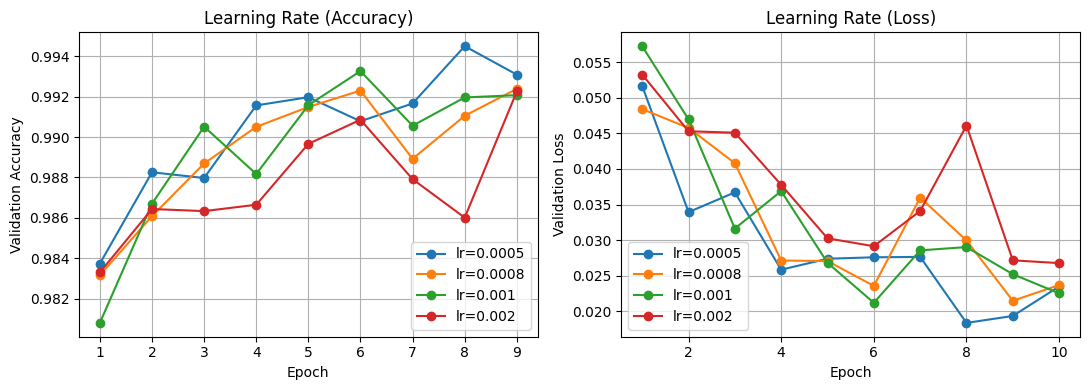

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[selected] lr = 0.0005

*** SWEEP: weight_decay

***[RUN] weight_decay=0.0001 | seed=42
    hparams: activation=gelu, depth=3, dropout_p=0.0, lr=0.0005, optimizer=adam, use_bn=False, weight_decay=0.0001, weight_init=xavier, width=128


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | GELU               | 0      | train
1 | encoder   | Sequential         | 886 K  | train
2 | head      | Sequential         | 296 K  | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.731     Total estimated model params size (MB)
20        Modules in train mode
0         Modules in eval mode


Epoch 9: 100%|██████████| 860/860 [00:04<00:00, 174.98it/s, v_num=3, train_loss_step=0.00227, val_loss=0.0235, val_acc=0.993, lr=0.0005, train_loss_epoch=0.0262, train_acc=0.992] 

`Trainer.fit` stopped: `max_epochs=10` reached.


...

***[RESULT] weight_decay=0.0005 → best_val_acc=0.9927 (epoch 6), final_val_acc=0.9907 | best_val_loss=0.0223 (epoch 6), final_val_loss=0.0232


***[RUN] weight_decay=0.001 | seed=42
    hparams: activation=gelu, depth=3, dropout_p=0.0, lr=0.0005, optimizer=adam, use_bn=False, weight_decay=0.001, weight_init=xavier, width=128


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | GELU               | 0      | train
1 | encoder   | Sequential         | 886 K  | train
2 | head      | Sequential         | 296 K  | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.731     Total estimat

Epoch 9: 100%|██████████| 860/860 [00:04<00:00, 175.58it/s, v_num=5, train_loss_step=0.181, val_loss=0.0303, val_acc=0.990, lr=0.0005, train_loss_epoch=0.0416, train_acc=0.986]   

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 860/860 [00:04<00:00, 174.95it/s, v_num=5, train_loss_step=0.181, val_loss=0.0303, val_acc=0.990, lr=0.0005, train_loss_epoch=0.0416, train_acc=0.986]
***[RESULT] weight_decay=0.001 → best_val_acc=0.9913 (epoch 6), final_val_acc=0.9912 | best_val_loss=0.0271 (epoch 6), final_val_loss=0.0303

       param  value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
weight_decay 0.0001      0.994501           8       0.993092       0.018377                8        0.023491
weight_decay 0.0005      0.992684           6       0.990731       0.022327                6        0.023202
weight_decay 0.0010      0.991268           6       0.991202       0.027099                6        0.030325


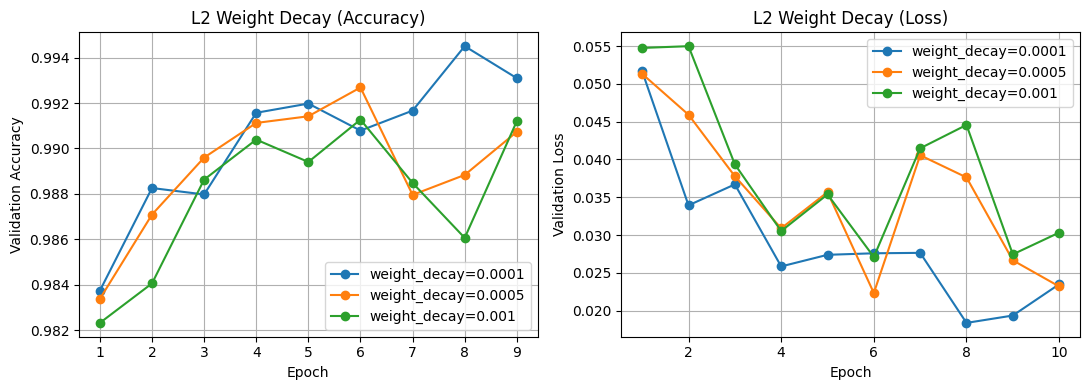

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[selected] weight_decay = 0.0001

*** SWEEP: activation

***[RUN] activation=relu | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.0, lr=0.0005, optimizer=adam, use_bn=False, weight_decay=0.0001, weight_init=xavier, width=128


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | ReLU               | 0      | train
1 | encoder   | Sequential         | 886 K  | train
2 | head      | Sequential         | 296 K  | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.731     Total estimated model params size (MB)
20        Modules in train mode
0         Modules in eval mode


Epoch 9: 100%|██████████| 860/860 [00:04<00:00, 174.90it/s, v_num=6, train_loss_step=0.00563, val_loss=0.0236, val_acc=0.992, lr=0.0005, train_loss_epoch=0.0282, train_acc=0.990] 

`Trainer.fit` stopped: `max_epochs=10` reached.


...

***[RESULT] activation=tanh → best_val_acc=0.9916 (epoch 6), final_val_acc=0.9908 | best_val_loss=0.0237 (epoch 10), final_val_loss=0.0237


***[RUN] activation=sigmoid | seed=42
    hparams: activation=sigmoid, depth=3, dropout_p=0.0, lr=0.0005, optimizer=adam, use_bn=False, weight_decay=0.0001, weight_init=xavier, width=128


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | Sigmoid            | 0      | train
1 | encoder   | Sequential         | 886 K  | train
2 | head      | Sequential         | 296 K  | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.731     Total estimat

Epoch 9: 100%|██████████| 860/860 [00:04<00:00, 175.87it/s, v_num=11, train_loss_step=0.234, val_loss=0.0386, val_acc=0.988, lr=0.0005, train_loss_epoch=0.0608, train_acc=0.981]  

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 860/860 [00:04<00:00, 175.22it/s, v_num=11, train_loss_step=0.234, val_loss=0.0386, val_acc=0.988, lr=0.0005, train_loss_epoch=0.0608, train_acc=0.981]
***[RESULT] activation=sigmoid → best_val_acc=0.9882 (epoch 9), final_val_acc=0.9882 | best_val_loss=0.0369 (epoch 9), final_val_loss=0.0386

     param     value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
activation      relu      0.994320           8       0.992347       0.016799                8        0.023558
activation      gelu      0.994072           9       0.994072       0.017622                9        0.019653
activation leakyrelu      0.993462           6       0.991305       0.018225               10        0.018225
activation       elu      0.992596           8       0.990339       0.025113               10        0.025113
activation      tanh      0.991625           6       0.990765       0.023737               10        0.023737
activation   sigmoid

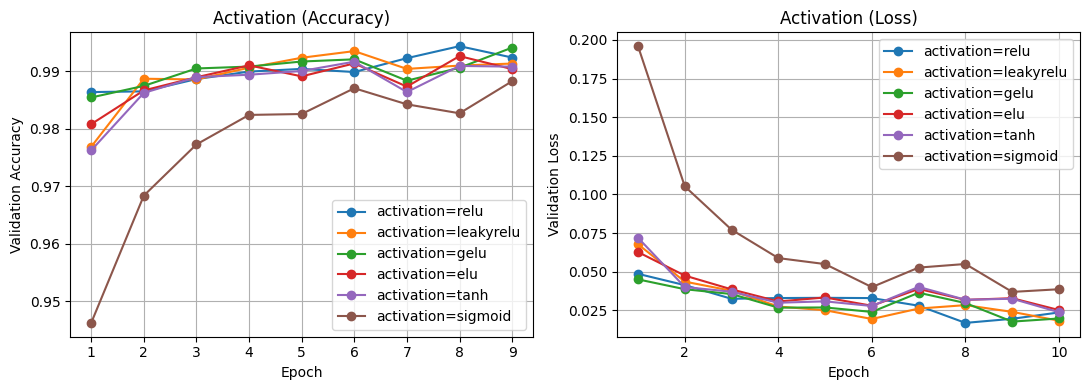

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[selected] activation = relu

*** SWEEP: weight_init

***[RUN] weight_init=he | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.0, lr=0.0005, optimizer=adam, use_bn=False, weight_decay=0.0001, weight_init=he, width=128


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | ReLU               | 0      | train
1 | encoder   | Sequential         | 886 K  | train
2 | head      | Sequential         | 296 K  | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.731     Total estimated model params size (MB)
20        Modules in train mode
0         Modules in eval mode


Epoch 9: 100%|██████████| 860/860 [00:05<00:00, 164.86it/s, v_num=2, train_loss_step=0.00129, val_loss=0.0364, val_acc=0.989, lr=0.0005, train_loss_epoch=0.0321, train_acc=0.989] 

`Trainer.fit` stopped: `max_epochs=10` reached.


...



***[RUN] weight_init=xavier | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.0, lr=0.0005, optimizer=adam, use_bn=False, weight_decay=0.0001, weight_init=xavier, width=128


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | ReLU               | 0      | train
1 | encoder   | Sequential         | 886 K  | train
2 | head      | Sequential         | 296 K  | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.731     Total estimat

Epoch 9: 100%|██████████| 860/860 [00:05<00:00, 169.74it/s, v_num=3, train_loss_step=0.0875, val_loss=0.0206, val_acc=0.993, lr=0.0005, train_loss_epoch=0.0296, train_acc=0.991]  

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 860/860 [00:05<00:00, 169.03it/s, v_num=3, train_loss_step=0.0875, val_loss=0.0206, val_acc=0.993, lr=0.0005, train_loss_epoch=0.0296, train_acc=0.991]
***[RESULT] weight_init=xavier → best_val_acc=0.9930 (epoch 9), final_val_acc=0.9930 | best_val_loss=0.0200 (epoch 9), final_val_loss=0.0206

      param  value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
weight_init     he      0.993604           8       0.992026       0.022684                8        0.036446
weight_init xavier      0.993049           9       0.993049       0.020008                9        0.020608


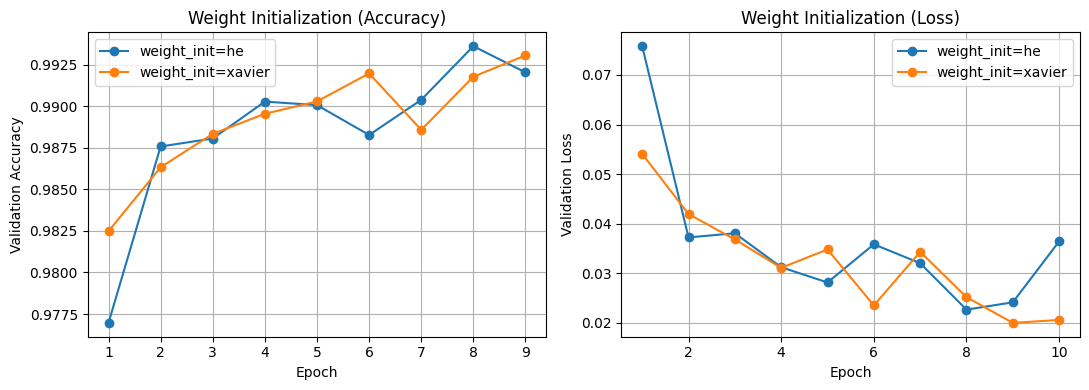

Seed set to 42


[selected] weight_init = he

*** SWEEP: optimizer

***[RUN] optimizer=adam | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.0, lr=0.0005, optimizer=adam, use_bn=False, weight_decay=0.0001, weight_init=he, width=128


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | ReLU               | 0      | train
1 | encoder   | Sequential         | 886 K  | train
2 | head      | Sequential         | 296 K  | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.731     Total estimat

Epoch 9: 100%|██████████| 860/860 [00:04<00:00, 172.43it/s, v_num=4, train_loss_step=0.00129, val_loss=0.0364, val_acc=0.989, lr=0.0005, train_loss_epoch=0.0321, train_acc=0.989] 

`Trainer.fit` stopped: `max_epochs=10` reached.


...

***[RESULT] optimizer=sgd → best_val_acc=0.9881 (epoch 6), final_val_acc=0.9878 | best_val_loss=0.0312 (epoch 10), final_val_loss=0.0312


***[RUN] optimizer=rmsprop | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.0, lr=0.0005, optimizer=rmsprop, use_bn=False, weight_decay=0.0001, weight_init=he, width=128


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | ReLU               | 0      | train
1 | encoder   | Sequential         | 886 K  | train
2 | head      | Sequential         | 296 K  | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.731     Total estimat

Epoch 9: 100%|██████████| 860/860 [00:04<00:00, 180.42it/s, v_num=7, train_loss_step=0.297, val_loss=0.0505, val_acc=0.985, lr=0.0005, train_loss_epoch=0.0918, train_acc=0.974]   

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 860/860 [00:04<00:00, 179.64it/s, v_num=7, train_loss_step=0.297, val_loss=0.0505, val_acc=0.985, lr=0.0005, train_loss_epoch=0.0918, train_acc=0.974]
***[RESULT] optimizer=rmsprop → best_val_acc=0.9848 (epoch 6), final_val_acc=0.9844 | best_val_loss=0.0503 (epoch 8), final_val_loss=0.0505

    param   value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
optimizer    adam      0.993604           8       0.992026       0.022684                8        0.036446
optimizer   adamw      0.992909           6       0.991920       0.025206               10        0.025206
optimizer     sgd      0.988117           6       0.987802       0.031160               10        0.031160
optimizer rmsprop      0.984776           6       0.984387       0.050343                8        0.050455


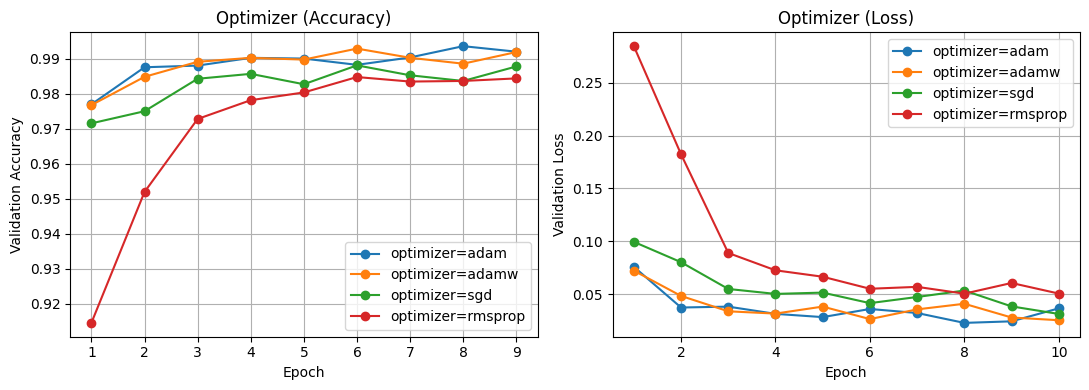

[selected] optimizer = adam

Best baseline after all sweeps:
 batch_size: 64
 lr: 0.0005
 optimizer: adam
 weight_decay: 0.0001
 activation: relu
 width: 128
 depth: 3
 dropout_p: 0.0
 use_bn: False
 weight_init: he


In [7]:
for name, title, values in sweeps:
    
    print(f"\n*** SWEEP: {name}")

    if name == "batch_size":
        bs_eval = BatchSizeEvaluator(
            base=baseline,
            epochs=EPOCHS_SWEEP,
            seed=SEED,
            plot=True,
            dm_kwargs={
                "data_dir": "./datasets",
                "num_workers": 0,
                "val_size": 5000,
                "augment": True,
                "pin_memory": True,
            },
        )
        df_bs = bs_eval.run(values, title=title)
        baseline["batch_size"] = cast_like(df_bs.iloc[0]["value"], baseline["batch_size"])
        print(f"[selected] batch_size = {baseline['batch_size']}")
        continue

    dm = MNISTDataModule(
        batch_size=int(baseline["batch_size"]),
        augment=True
    )
    
    evaluator = HyperParameterEvaluator(
        dm=dm,
        epochs=EPOCHS_SWEEP,
        seed=SEED,
        plot=True,
        base=baseline,
        log_root="logs/mnist_cnn_sweeps",
        model_cls=MNISTCNN,
    )

    results_table = evaluator.sweep(name, values, title=title)
    chosen = cast_like(results_table.iloc[0]["value"], baseline[name])
    baseline[name] = chosen
    print(f"[selected] {name} = {baseline[name]}")

print("\nBest baseline after all sweeps:")
for k, v in baseline.items():
    print(f" {k}: {v}")

### Final training on the consolidated best configuration

In [8]:
# Since this is our last run, set more epochs and configure early stopping
FINAL_EPOCHS = 25
PATIENCE = 5
EARLY_STOPPING_MIN_DELTA = 1e-4
CHECKPOINT_TOP_K = 1
SCHEDULER="cosine"
LEARNING_RATE_FLOOR = 1e-5
LOG_ROOT = "logs"
EXP_NAME = "mnist_cnn_final"

# Build a fresh DataModule with the chosen batch_size
dm = MNISTDataModule(
    batch_size=int(baseline["batch_size"]),
    augment=True
)

model = MNISTCNN(
	lr=float(baseline["lr"]),
	optimizer=str(baseline["optimizer"]),
	weight_decay=float(baseline["weight_decay"]),
	activation=str(baseline["activation"]),
	width=int(baseline["width"]),
	depth=int(baseline["depth"]),
	dropout_p=float(baseline["dropout_p"]),
	use_bn=bool(baseline["use_bn"]),
	weight_init=str(baseline["weight_init"]),
	scheduler=SCHEDULER,
	t_max=FINAL_EPOCHS,
	eta_min=LEARNING_RATE_FLOOR,
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=PATIENCE,
        min_delta=EARLY_STOPPING_MIN_DELTA
    ),
    ModelCheckpoint(
        monitor="val_acc",
        mode="max",
        save_top_k=CHECKPOINT_TOP_K,
        dirpath="checkpoints",
        filename="mnist_cnn_best"
    )
]

csv_logger = CSVLogger(
    save_dir=LOG_ROOT,
    name=EXP_NAME
)

trainer = L.Trainer(
    max_epochs=FINAL_EPOCHS,
    accelerator="auto",
    devices="auto",
    precision="32-true",
    log_every_n_steps=10,
    deterministic=True,
    num_sanity_val_steps=0,
    callbacks=callbacks,
    logger=csv_logger,
)

trainer.fit(model, datamodule=dm)
trainer.test(ckpt_path="best", datamodule=dm)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/logus/env/iscte/mnist_digits/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /home/logus/env/iscte/mnist_digits/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | act       | ReLU               | 0      | train
1 | encoder   | Sequential         | 886 K  | train
2 | head      | Sequential         | 296 K  | train
3 | criterion | CrossEntropyLoss   | 0      | train
4 | acc_tr    | MulticlassAccuracy | 0      | train
5 | acc_va    | MulticlassAccuracy | 0      | train
6 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.731     Total es

Epoch 24: 100%|██████████| 860/860 [00:07<00:00, 112.57it/s, v_num=1, train_loss_step=0.0654, val_loss=0.0131, val_acc=0.996, lr=1.19e-5, train_loss_epoch=0.00767, train_acc=0.997]  

`Trainer.fit` stopped: `max_epochs=25` reached.


Epoch 24: 100%|██████████| 860/860 [00:07<00:00, 112.51it/s, v_num=1, train_loss_step=0.0654, val_loss=0.0131, val_acc=0.996, lr=1.19e-5, train_loss_epoch=0.00767, train_acc=0.997]


Restoring states from the checkpoint path at /home/logus/env/iscte/mnist_digits/checkpoints/mnist_cnn_best-v1.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/logus/env/iscte/mnist_digits/checkpoints/mnist_cnn_best-v1.ckpt


Testing DataLoader 0: 100%|██████████| 157/157 [00:00<00:00, 314.05it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9961090683937073
        test_loss          0.010769112035632133
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.010769112035632133, 'test_acc': 0.9961090683937073}]